# Trabalho Prático PDI - Correlação de Astrous

Alunos: Adriel Ferreira & Kamily Assis

## Bibliotecas

In [41]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

## Funções

### parametros

In [42]:
def validar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    erros = []

    if not (1 <= dilatacao <= 5):
        erros.append(f"Dilatação inválida: {dilatacao}. Deve ser um inteiro entre 1 e 5.")

    if not (1 <= stride <= 5):
        erros.append(f"Stride inválido: {stride}. Deve ser um inteiro entre 1 e 5.")

    if len(dimensoes) != 2 or (dimensoes[0] <= 0 or dimensoes[1] <= 0):
        erros.append(f"Dimensões inválidas: {dimensoes}. Deve ser uma lista com dois inteiros positivos [m, n].")

    ativacoes_validas = ["relu", "identity"]
    if ativacao not in ativacoes_validas:
        erros.append(f"Ativação inválida: '{ativacao}'. Deve ser uma das: {ativacoes_validas}.")

    if erros:
        return erros

    return True

In [43]:
def ler_parametros(filepath: str):
    
    with open(filepath, 'r') as file:
        parametros = json.load(file)
    
    stride = parametros.get("stride")
    dilatacao = parametros.get("dilatacao")
    dimensoes = parametros.get("dimensoes")
    filtro = np.array(parametros.get("filtro"))
    ativacao = parametros.get("ativacao")
    
    return stride, dilatacao, dimensoes, filtro, ativacao

### canais RGB

In [44]:
def exibir_canais_rgb(r_color, g_color, b_color, rgb_array):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_array)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(r_color)
    plt.title("Canal R")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(g_color)
    plt.title("Canal G")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(b_color)
    plt.title("Canal B")
    plt.axis("off")

    plt.show()

In [45]:
def processar_canais_rgb(image):

    img = Image.open(image)
    rgb_array = np.array(img)

    r = rgb_array[:, :, 0]
    g = rgb_array[:, :, 1]
    b = rgb_array[:, :, 2]

    r_color = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=2)
    g_color = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=2)
    b_color = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=2)

    return r_color, g_color, b_color, rgb_array


### correlação atrous

In [46]:
def atrous_correlate(image, dilation_rate, stride, filter_dimensions, filter_values, activation_function):
    H, W, C = image.shape
    kH, kW = filter_dimensions
    kernel = np.array(filter_values).reshape(kH, kW)

    effective_kH = kH + (kH - 1) * (dilation_rate - 1)
    effective_kW = kW + (kW - 1) * (dilation_rate - 1)

    out_H = (H - effective_kH) // stride + 1
    out_W = (W - effective_kW) // stride + 1

    output = np.zeros((out_H, out_W, C))

    for c in range(C):
        for i in range(out_H):
            for j in range(out_W):
                soma = 0
                for ki in range(kH):
                    for kj in range(kW):
                        pixel_i = i * stride + ki * dilation_rate
                        pixel_j = j * stride + kj * dilation_rate
                        soma += image[pixel_i, pixel_j, c] * kernel[ki, kj]
                output[i, j, c] = activation_function(soma)

    return output

In [47]:
def histogram_expansion(image):
    img_min = image.min()
    img_max = image.max()
    if img_max == img_min:
        return np.zeros_like(image)
    return (image - img_min) / (img_max - img_min) * 255

In [48]:

def aplicar_ativacao(valor, tipo):
    if tipo == "ReLU":
        return max(0, valor)
    return valor  # Identidade

def correlacao_dilatada(caminho_imagem, caminho_config):
    # 1. Carregar Configurações
    with open(caminho_config, 'r') as f:
        conf = json.load(f)
    
    r = conf['r']
    s = conf['stride']
    m, n = conf['m'], conf['n']
    mask = np.array(conf['mask'])
    ativacao = conf['activation']

    # 2. Carregar Imagem
    img = Image.open(caminho_imagem).convert('RGB')
    img_array = np.array(img).astype(float)
    h_in, w_in, channels = img_array.shape

    # 3. Calcular Dimensões de Saída (Sem Padding)
    # Tamanho efetivo do filtro com dilatação
    m_eff = m + (m - 1) * (r - 1)
    n_eff = n + (n - 1) * (r - 1)

    h_out = (h_in - m_eff) // s + 1
    w_out = (w_in - n_eff) // s + 1

    # Criar matriz de saída vazia
    output = np.zeros((h_out, w_out, channels))

    # 4. Loop de Correlação (Independente por Canal)
    for c in range(channels):
        for i in range(h_out):
            for j in range(w_out):
                soma = 0
                # Percorrer a máscara
                for km in range(m):
                    for kn in range(n):
                        # Cálculo do índice com Stride e Dilatação
                        pos_h = i * s + km * r
                        pos_w = j * s + kn * r
                        
                        soma += img_array[pos_h, pos_w, c] * mask[km, kn]
                
                # Aplica Função de Ativação
                output[i, j, c] = aplicar_ativacao(soma, ativacao)

    # Converter de volta para imagem (0-255)
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output,Image.fromarray(output)

# --- Execução ---
# Substitua 'sua_imagem.jpg' pelo nome do seu arquivo

"""
resultado = correlacao_dilatada('Imagens/Shapes.png', 'config.json')
resultado.save('resultado_dilatado.jpg')
resultado.show()
"""

"\nresultado = correlacao_dilatada('Imagens/Shapes.png', 'config.json')\nresultado.save('resultado_dilatado.jpg')\nresultado.show()\n"

### Testes

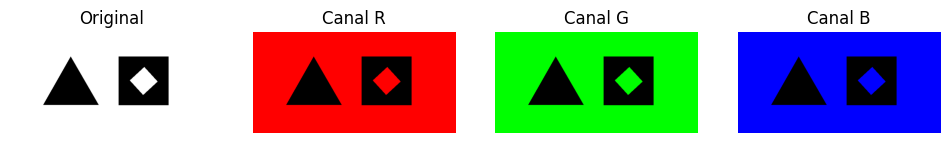

array type: uint8


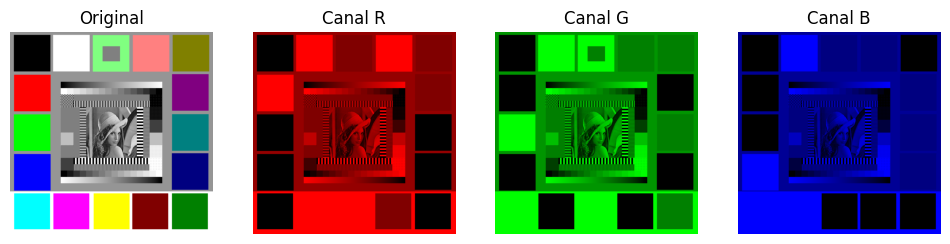

array type: uint8


In [49]:
image_path = ["Imagens/shapes.png", "Imagens/testpat.tif"]

for image in image_path:
    r, g, b, rgb = processar_canais_rgb(image)
    exibir_canais_rgb(r, g, b, rgb)
    print("array type:", rgb.dtype)

In [50]:
path = "parametros/parametros.json"
stride, dilatacao, dimensoes, filtro, ativacao = ler_parametros(path)
validade = validar_parametros(stride, dilatacao, dimensoes, filtro, ativacao)

print(f"Stride: {stride}")
print(f"Dilatação: {dilatacao}")
print(f"Dimensões do filtro: {dimensoes}")
print(f"Filtro:\n{filtro}")
print(f"Ativação: {ativacao}")
print(f"Validade dos parâmetros: {'Válidos' if validade else 'Inválidos'}")

Stride: 2
Dilatação: 2
Dimensões do filtro: [3, 3]
Filtro:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
Ativação: relu
Validade dos parâmetros: Válidos


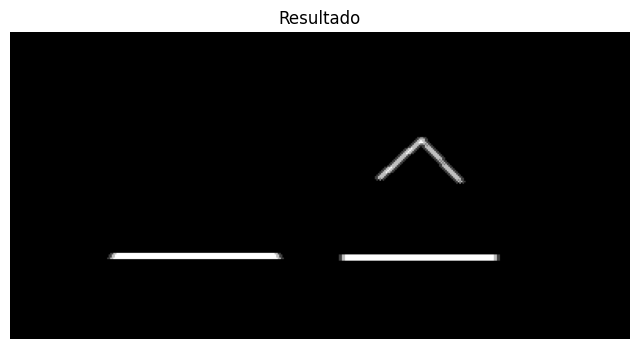

In [54]:
sobel_h_values = [-1, -2, -1, 0, 0, 0, 1, 2, 1]
img_array = np.array(Image.open("Imagens/shapes.png"))

result = atrous_correlate(
    image=img_array,
    dilation_rate=4,
    stride=stride,
    filter_dimensions=dimensoes,
    filter_values=sobel_h_values,
    activation_function=relu
)

result = np.abs(result)
result = histogram_expansion(result)

plt.figure(figsize=(8, 8))
plt.imshow(result.astype(np.uint8))
plt.axis("off")
plt.title("Resultado")
plt.show()

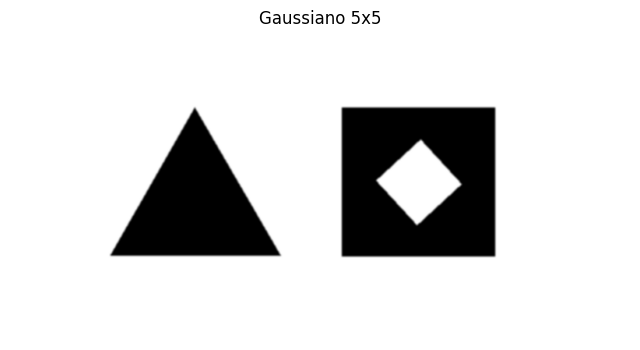

In [ ]:
gaussian_5x5 = [1/256,  4/256,  6/256,  4/256, 1/256,
                4/256, 16/256, 24/256, 16/256, 4/256,
                6/256, 24/256, 36/256, 24/256, 6/256,
                4/256, 16/256, 24/256, 16/256, 4/256,
                1/256,  4/256,  6/256,  4/256, 1/256]

result = atrous_correlate(
    image=img_array,
    dilation_rate=1,
    stride=1,
    filter_dimensions=(5, 5),
    filter_values=gaussian_5x5,
    activation_function=identity
)

plt.figure(figsize=(8, 8))
plt.imshow(np.clip(result, 0, 255).astype(np.uint8))
plt.axis("off")
plt.title("Gaussiano 5x5")
plt.show()

In [56]:
output, img = resultado = correlacao_dilatada('Imagens/Shapes.png', 'config.json')

In [57]:
img_array.shape, output

((400, 800, 3),
 array([[[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        ...,
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [25

In [ ]:
gaussian_5x5 = [1/256,  4/256,  6/256,  4/256, 1/256,
                4/256, 16/256, 24/256, 16/256, 4/256,
                6/256, 24/256, 36/256, 24/256, 6/256,
                4/256, 16/256, 24/256, 16/256, 4/256,
                1/256,  4/256,  6/256,  4/256, 1/256]

result = atrous_correlate(
    image=img_array,
    dilation_rate=1,
    stride=1,
    filter_dimensions=(5, 5),
    filter_values=gaussian_5x5,
    activation_function=identity
)

plt.figure(figsize=(8, 8))
plt.imshow(np.clip(result, 0, 255).astype(np.uint8))
plt.axis("off")
plt.title("Gaussiano 5x5")
plt.show()